# E1 Structural Misspecification

展示型 notebook：训练 E0 的 SIR workflow，并在 SEIR truth -> SIR inference 的 structural misspecification 下评估 posterior、feature-level PPC、curve-level PPC，并导出结果报告。

In [2]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "src").exists():
        ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate project root containing 'src'.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
OUTPUTS_ROOT = ROOT / "outputs"
print("Project root:", ROOT)
print("Outputs root:", OUTPUTS_ROOT)

from IPython.display import Markdown, display

from src.config import setup_environment
from src.diagnostics import evaluate_curve_level_ppc
from src.experiments import (
    build_E1_results_report,
    run_E1_evaluation,
    run_E1_example_case,
    run_extended_E1_feature_evaluation,
)
from src.plotting import (
    plot_curve_level_ppc_summary,
    plot_e0_overall_figure,
    plot_e1_example_case,
    plot_feature_residuals,
    plot_training_loss,
    plot_truth_vs_median_scatter,
)
from src.simulators import simulate_case_E1, simulate_curve
from src.workflow import train_workflow

Project root: /Users/jijiayi/Documents/25WS/GNN/GNN_Final_Project
Outputs root: /Users/jijiayi/Documents/25WS/GNN/GNN_Final_Project/outputs


In [3]:
missing = []
for pkg in ["bayesflow", "tensorflow", "keras"]:
    try:
        __import__(pkg)
        print(f"[ok] {pkg}")
    except Exception as e:
        missing.append(pkg)
        print(f"[missing] {pkg}: {e}")

if missing:
    print("\nInstall missing packages in the current kernel environment, for example:")
    print("python -m pip install bayesflow==2.0.7 tensorflow==2.17.0 keras==3.9.0")
else:
    print("\nBackend check passed.")

INFO:bayesflow:Using backend 'tensorflow'


[ok] bayesflow
[ok] tensorflow
[ok] keras

Backend check passed.


In [4]:
# Optional install cell.
# Uncomment and run this cell if the backend packages are missing,
# then restart the kernel before continuing.

import sys
print(sys.executable)
# !{sys.executable} -m pip install bayesflow==2.0.7 tensorflow==2.17.0 keras==3.9.0 numpy==1.26.4 pandas==2.3.3 scipy==1.15.3 matplotlib==3.8.4 seaborn

/opt/anaconda3/envs/bayesflow311/bin/python


INFO:bayesflow:Building dataset from simulator instance of LambdaSimulator.
INFO:bayesflow:Building on a test batch.


bayesflow: 2.0.7
tensorflow: 2.17.0
keras: 3.9.0
numpy: 1.26.4
pandas: 2.3.3
scipy: 1.15.3
matplotlib: 3.8.4
Epoch 1/12
60/60 - 15s - 246ms/step - loss: 2.5441
Epoch 2/12
60/60 - 3s - 50ms/step - loss: 1.4825
Epoch 3/12
60/60 - 3s - 49ms/step - loss: 0.9436
Epoch 4/12
60/60 - 3s - 50ms/step - loss: 0.4041
Epoch 5/12
60/60 - 3s - 50ms/step - loss: 0.1514
Epoch 6/12
60/60 - 3s - 49ms/step - loss: -1.6706e-01
Epoch 7/12
60/60 - 3s - 50ms/step - loss: -4.1431e-01
Epoch 8/12
60/60 - 3s - 50ms/step - loss: -5.3902e-01
Epoch 9/12
60/60 - 3s - 49ms/step - loss: -7.0491e-01
Epoch 10/12
60/60 - 3s - 49ms/step - loss: -8.0065e-01
Epoch 11/12
60/60 - 3s - 50ms/step - loss: -8.9503e-01
Epoch 12/12
60/60 - 3s - 50ms/step - loss: -9.4798e-01


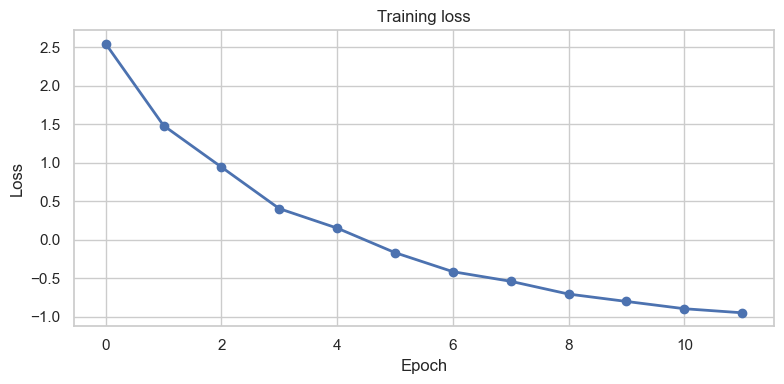

In [5]:
setup_environment(seed=42)
workflow_E0, history_E0 = train_workflow(seed=42)
plot_training_loss(history_E0)

## E1: Structural Misspecification

真实数据由 SEIR 模型生成，而推断仍使用 SIR 模型。这个实验代表的是推断模型忽略了潜伏阶段，希望观察 posterior 会出现何种偏差、过度自信或 predictive mismatch。

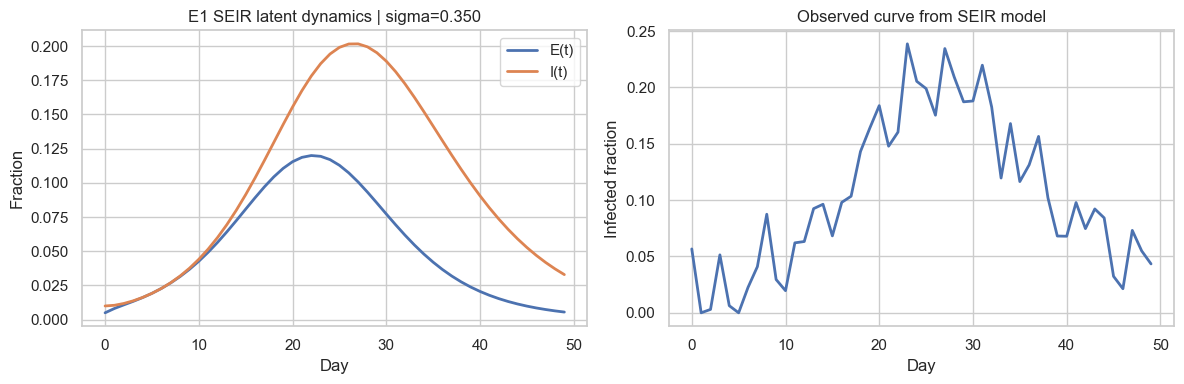

{'beta': 0.55, 'gamma': 0.18, 'sigma': 0.35, 'R0': 3.055555555555556, 'observed_curve': array([[0.05667229],
       [0.        ],
       [0.00300767],
       [0.05140534],
       [0.00631049],
       [0.        ],
       [0.02251832],
       [0.04096624],
       [0.08744821],
       [0.02952682],
       [0.01963224],
       [0.06207116],
       [0.06324832],
       [0.09242038],
       [0.09629975],
       [0.06825613],
       [0.09798209],
       [0.10344253],
       [0.14310555],
       [0.16399413],
       [0.1837904 ],
       [0.14781196],
       [0.16030636],
       [0.23863013],
       [0.20541011],
       [0.19892663],
       [0.17532912],
       [0.23445478],
       [0.20920064],
       [0.18719494],
       [0.18794735],
       [0.2196902 ],
       [0.18248507],
       [0.11958213],
       [0.16790062],
       [0.11643851],
       [0.13130882],
       [0.1565005 ],
       [0.1020299 ],
       [0.06811753],
       [0.06793101],
       [0.09781495],
       [0.0746909 ],
       [0

In [6]:
example_case = run_E1_example_case(beta=0.55, gamma=0.18, sigma=0.35, seed=3030)
plot_e1_example_case(
    example_case["seir_traj"],
    example_case["observed_curve"],
    example_case["time_grid"],
    example_case["sigma"],
    out_path=str(OUTPUTS_ROOT / "E1" / "E1_example_case.png"),
)
print(example_case)

这个 example case 用来直观展示 structural misspecification 的来源：真实 latent dynamics 里存在 exposed compartment `E`，因此感染显现会被推迟；但 SIR inference model 并不知道这个阶段，只能通过扭曲 `beta` 和 `gamma` 的后验来解释同样的观测曲线。

In [7]:
case_df, recovery_df, coverage_df, feature_case_df, feature_summary_df = run_E1_evaluation(
    workflow=workflow_E0,
    n_test=100,
    num_posterior_samples=2000,
    n_ppc_draws=100,
    seed=2026,
)
display(recovery_df.round(4))
display(coverage_df.round(4))
display(feature_summary_df.round(4))

,quantity,bias_mean_est,bias_median_est,MAE_median_est,RMSE_median_est,corr_truth_vs_median,avg_post_std
0,beta,-0.2011,-0.2065,0.2246,0.2657,0.7529,0.0492
1,gamma,-0.0445,-0.0401,0.0602,0.0810,0.8342,0.0472
2,R0,-0.8253,-0.8303,0.8895,1.7243,0.9393,0.1882


,quantity,nominal_50,empirical_50,diff_50,nominal_90,empirical_90,diff_90,avg_width50,avg_width90
0,beta,0.5,0.07,-0.43,0.9,0.30,-0.60,0.0689,0.1593
1,gamma,0.5,0.25,-0.25,0.9,0.56,-0.34,0.0685,0.1535
2,R0,0.5,0.10,-0.40,0.9,0.41,-0.49,0.2478,0.6130


,feature,nominal_50,empirical_50,diff_50,nominal_90,empirical_90,diff_90,bias_mean_pred,bias_median_pred,MAE_median_pred,RMSE_median_pred,avg_pred_std,avg_width50,avg_width90
0,peak_time,0.5,0.61,0.11,0.9,0.92,0.02,-1.6645,-2.3000,7.0900,10.7210,8.9639,14.3675,27.3145
1,peak_height,0.5,0.50,0.00,0.9,0.86,-0.04,-0.0113,-0.0124,0.0155,0.0210,0.0200,0.0250,0.0618
2,cumulative_infected,0.5,0.71,0.21,0.9,0.97,0.07,-0.0905,-0.1295,0.1810,0.2876,0.4531,0.5256,1.3824
3,early_growth_slope,0.5,0.48,-0.02,0.9,0.86,-0.04,0.0006,0.0006,0.0021,0.0027,0.0025,0.0033,0.0080


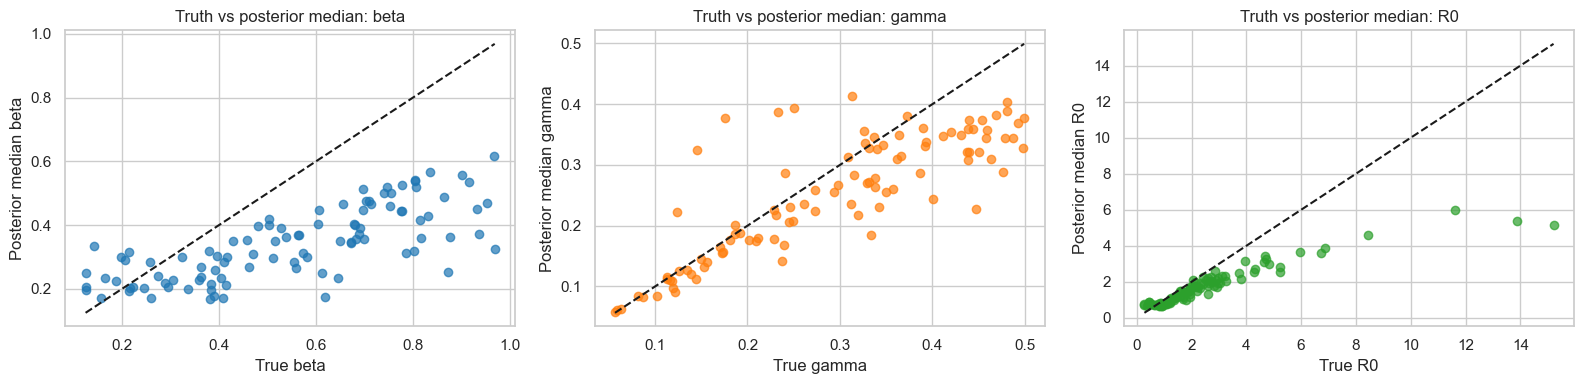

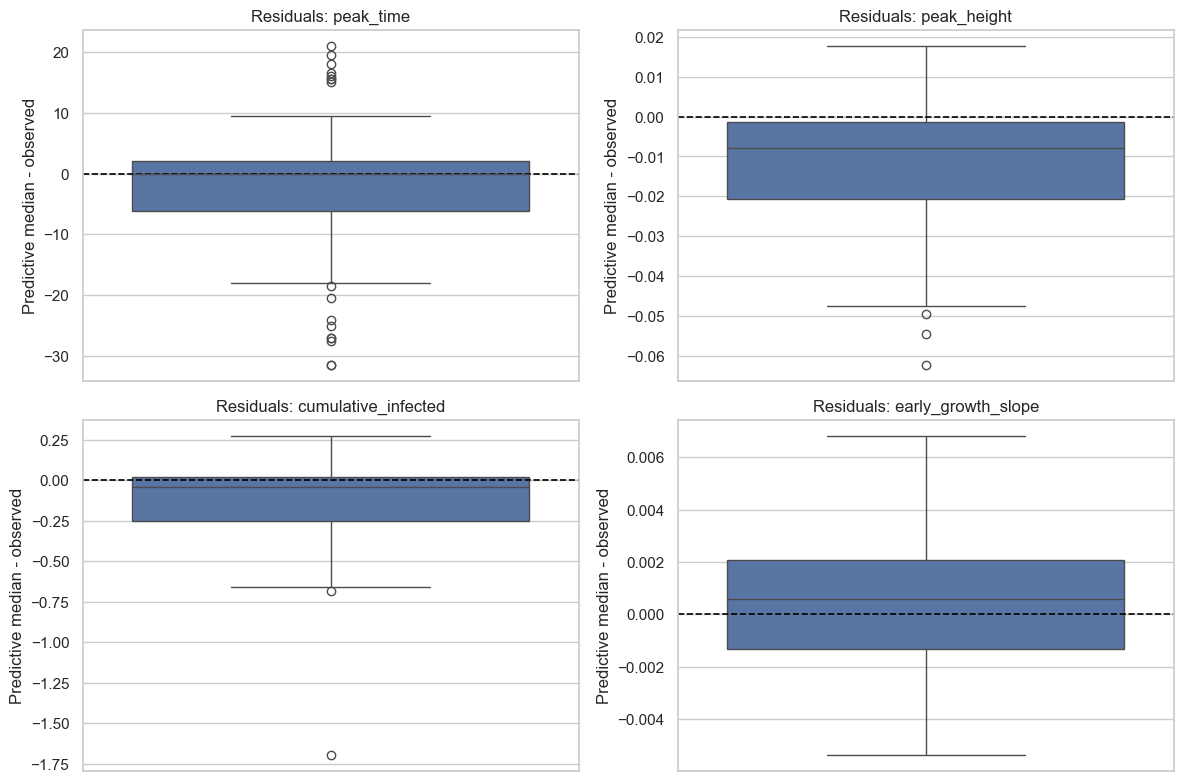

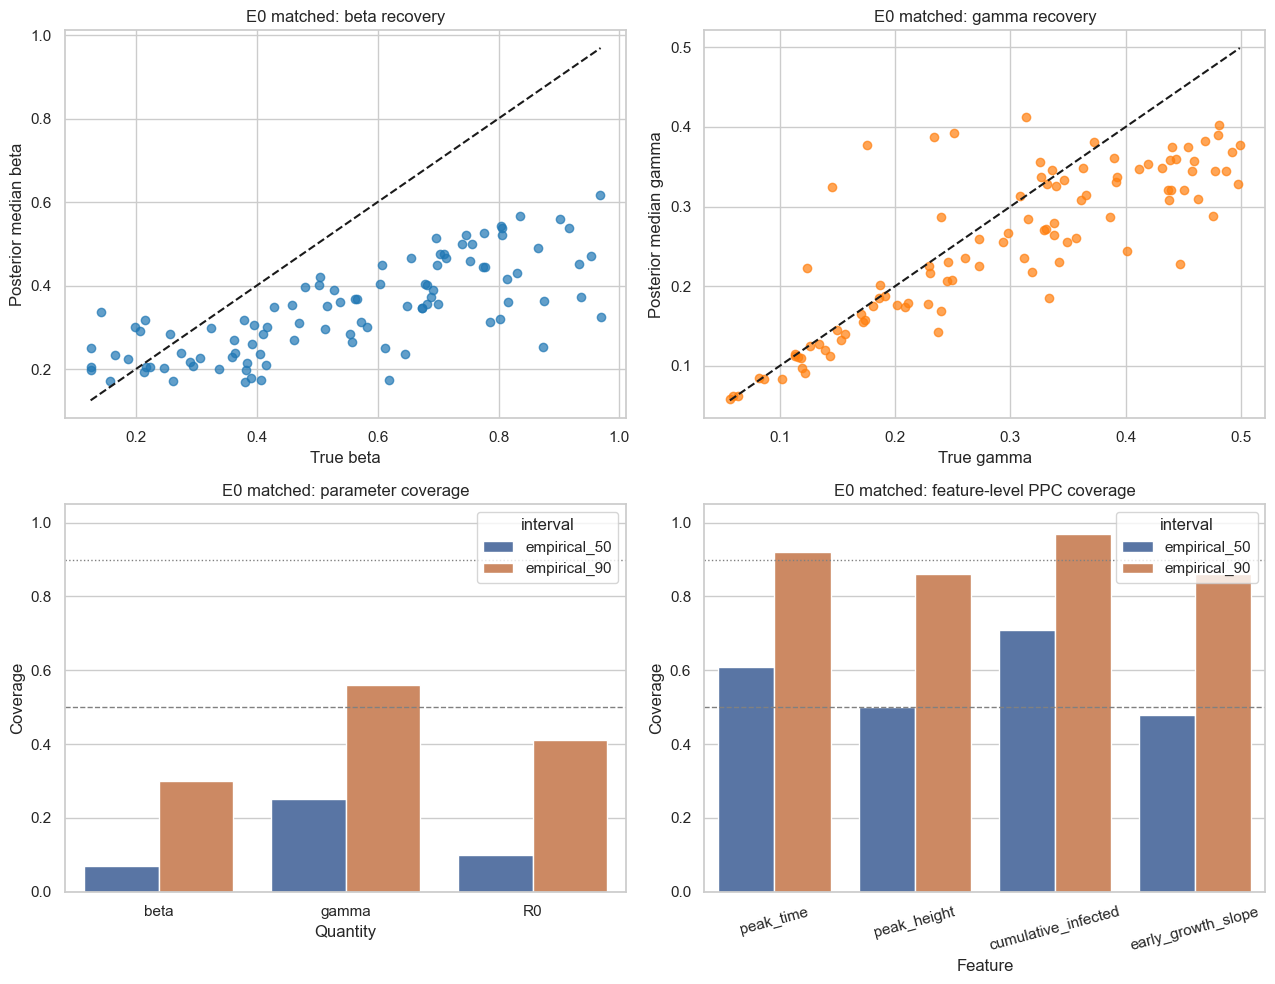

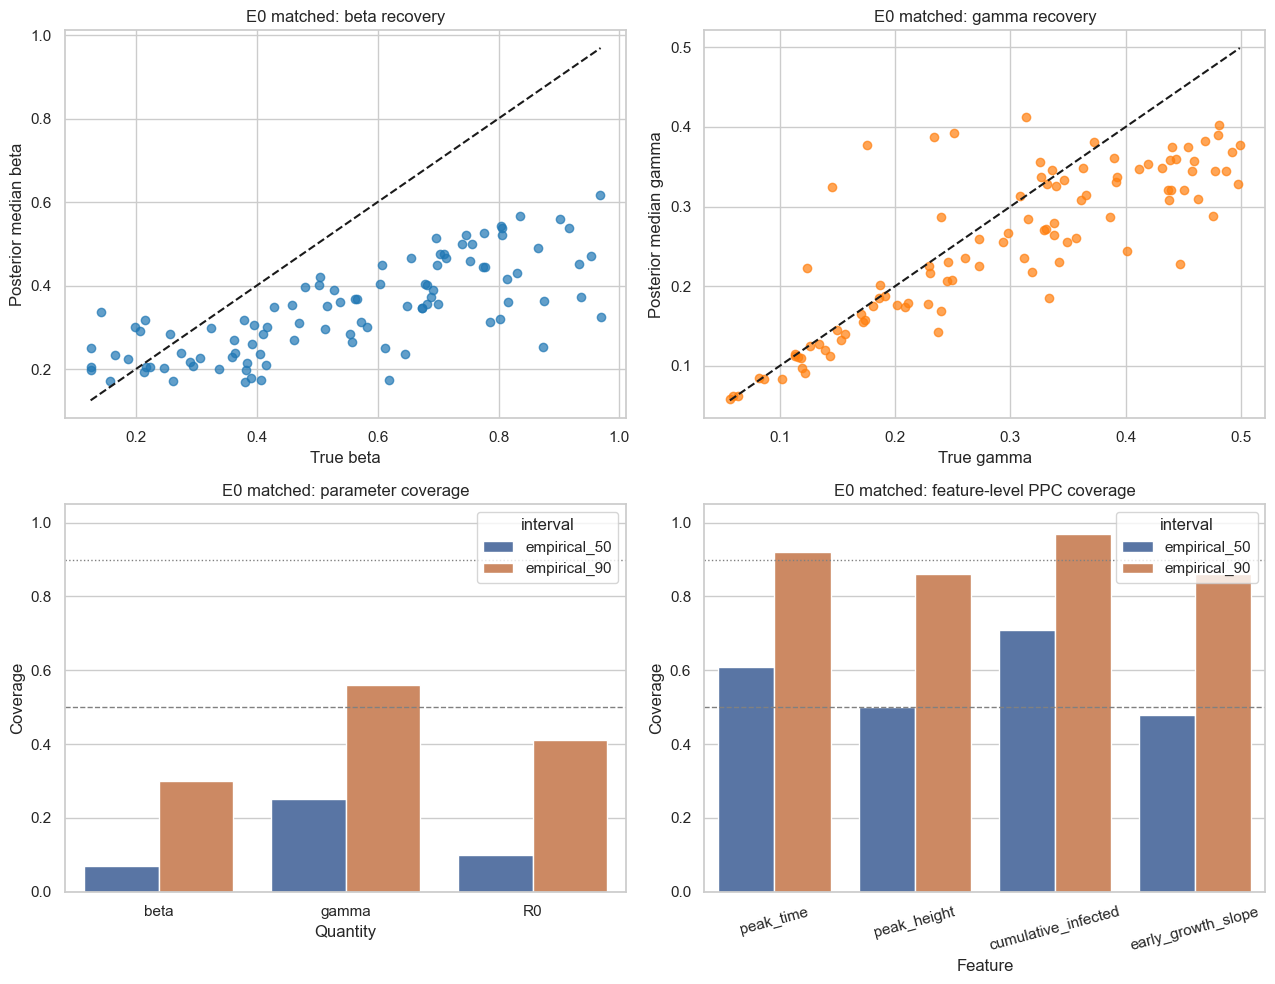

In [8]:
plot_truth_vs_median_scatter(case_df)
plot_feature_residuals(feature_case_df)
plot_e0_overall_figure(
    case_df,
    coverage_df,
    feature_summary_df,
    out_path=str(OUTPUTS_ROOT / "E1" / "E1_structural_overall_figure.png"),
)

这一部分对应 E1 的主结果：如果 SIR posterior 被拿去解释来自 SEIR 的观测曲线，我们可以直接从 recovery、coverage 和 coarse feature-level PPC 中看到 misspecification 是否主要影响 transmission-related quantities，还是已经明显波及更粗粒度的 predictive summaries。

In [9]:
extended_feature_case_df, extended_feature_summary_df = run_extended_E1_feature_evaluation(
    workflow=workflow_E0,
    n_test=100,
    num_posterior_samples=1000,
    n_ppc_draws=100,
    seed=2026,
)
display(extended_feature_summary_df.round(4))

,feature,nominal_50,empirical_50,diff_50,nominal_90,empirical_90,diff_90,bias_mean_pred,bias_median_pred,MAE_median_pred,RMSE_median_pred,avg_pred_std,avg_width50,avg_width90
0,peak_time,0.5,0.61,0.11,0.9,0.94,0.04,-1.6748,-2.0850,7.1550,10.9377,9.0284,14.2800,27.8020
1,peak_height,0.5,0.54,0.04,0.9,0.84,-0.06,-0.0111,-0.0122,0.0154,0.0205,0.0205,0.0258,0.0622
2,cumulative_infected,0.5,0.67,0.17,0.9,0.98,0.08,-0.0879,-0.1226,0.1744,0.2670,0.4579,0.5349,1.3748
3,early_growth_slope,0.5,0.47,-0.03,0.9,0.87,-0.03,0.0006,0.0006,0.0022,0.0028,0.0025,0.0033,0.0080
4,post_peak_decline_slope,0.5,0.43,-0.07,0.9,0.82,-0.08,0.0008,0.0015,0.0034,0.0059,0.0050,0.0036,0.0117
5,late_phase_auc,0.5,0.67,0.17,0.9,0.98,0.08,-0.0495,-0.0758,0.1345,0.2151,0.3133,0.3616,0.9234
6,time_to_half_peak_after_peak,0.5,0.74,0.24,0.9,0.94,0.04,0.2081,-0.1250,1.1850,1.9780,2.0049,2.2875,5.6685
7,late_to_early_mean_ratio,0.5,0.54,0.04,0.9,0.93,0.03,-0.1143,-0.1636,0.2386,0.3701,0.3470,0.4232,1.0531


这里把 E1 再往前推进一步：不仅看原来的四个 coarse summaries，也把更 dynamics-aware 的 extended features 放进 PPC。这样可以检验 structural misspecification 是否更容易在 peak 后衰减、late-phase mass、half-peak timing 这类 summary 上暴露出来。

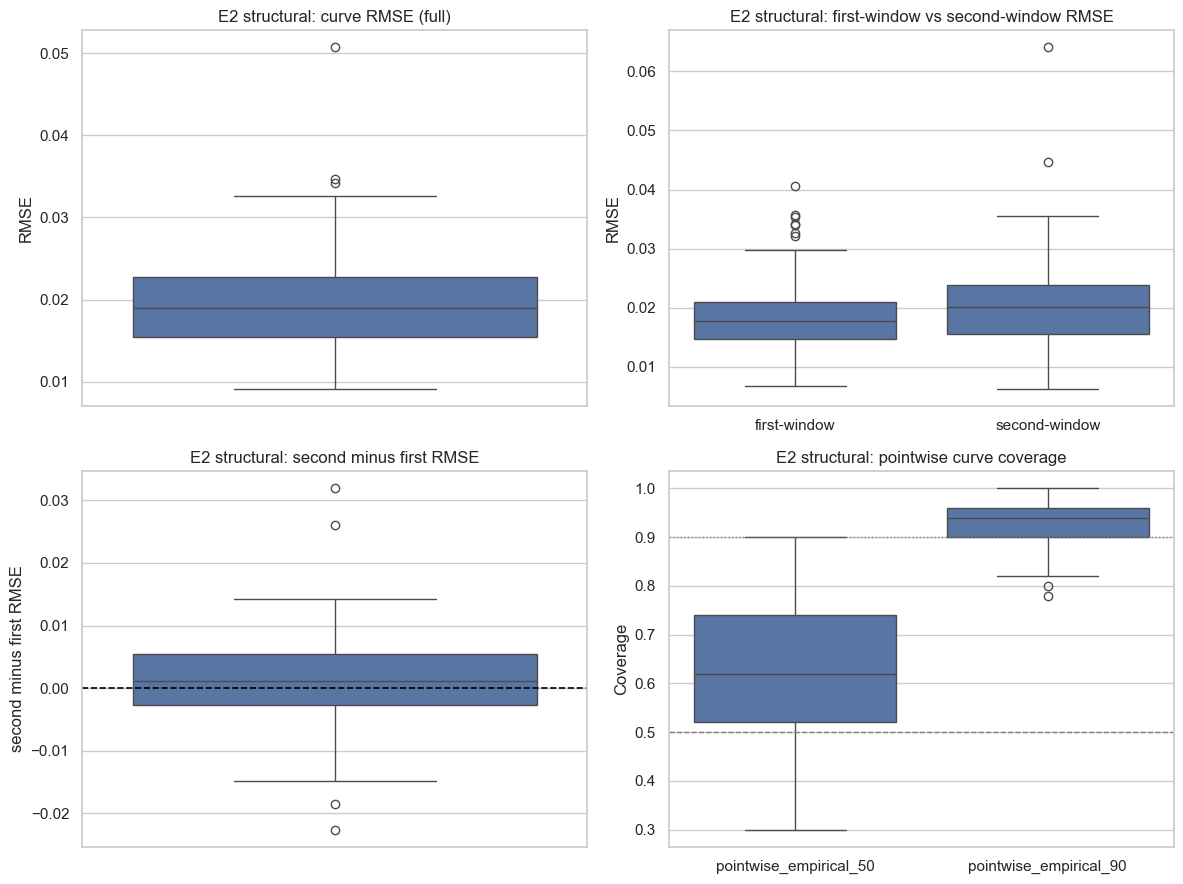

,metric,mean,std,median,q05,q95
0,pointwise_empirical_50,0.6206,0.1447,0.6200,0.3780,0.8400
1,pointwise_empirical_90,0.9282,0.0538,0.9400,0.8200,1.0000
2,curve_bias_full,-0.0051,0.0044,-0.0051,-0.0107,0.0013
3,curve_mae_full,0.0153,0.0054,0.0152,0.0078,0.0226
4,curve_rmse_full,0.0198,0.0062,0.0190,0.0114,0.0294
5,curve_bias_first,-0.0046,0.0050,-0.0042,-0.0156,0.0025
6,curve_mae_first,0.0147,0.0055,0.0142,0.0080,0.0278
7,curve_rmse_first,0.0188,0.0064,0.0177,0.0105,0.0327
8,curve_bias_second,-0.0056,0.0076,-0.0048,-0.0162,0.0050
9,curve_mae_second,0.0158,0.0070,0.0154,0.0075,0.0264


In [10]:
curve_case_df, curve_summary_df = evaluate_curve_level_ppc(
    workflow=workflow_E0,
    case_simulator=simulate_case_E1,
    predictive_curve_simulator=simulate_curve,
    n_test=100,
    num_posterior_samples=1000,
    n_ppc_draws=100,
    seed=2026,
    split_frac=0.5,
)
plot_curve_level_ppc_summary(
    curve_case_df,
    severity_label="structural",
    out_dir=str(OUTPUTS_ROOT / "E1" / "curve_level"),
)
display(curve_summary_df.round(4))

curve-level PPC 用来回答一个更直接的问题：即使参数 posterior 出现 distortion，SIR posterior predictive 是否仍能在整条曲线层面看起来“差不多合理”？如果可以，那么这会进一步支持一个重要结论：structural misspecification 可能先体现在 posterior reliability 上，而不是先体现在 visibly bad fit 上。

In [11]:
report_text = build_E1_results_report(
    recovery_df=recovery_df,
    coverage_df=coverage_df,
    feature_summary_df=feature_summary_df,
    curve_summary_df=curve_summary_df,
)
display(Markdown(report_text))

# E1 Structural Misspecification Report

## Setup

- Truth model: SEIR
- Inference model: SIR-trained BayesFlow amortizer
- Purpose: evaluate structural misspecification caused by ignoring the exposed compartment

## Key Findings

- Posterior median bias:
  - beta: -0.2065
  - gamma: -0.0401
  - R0: -0.8303
- Empirical 90% coverage:
  - beta: 0.3000
  - gamma: 0.5600
  - R0: 0.4100
- Feature-level PPC:
  - peak_time empirical 90% coverage: 0.9200
  - early_growth_slope empirical 50% coverage: 0.4800
- Curve-level PPC:
  - mean full-curve RMSE: 0.0198
  - mean pointwise empirical 90% coverage: 0.9282

## Interpretation

Under E1, the inference model is forced to explain SEIR-generated observations with a simpler SIR family. This primarily tests whether the missing latent exposure stage distorts parameter recovery, narrows posterior intervals too aggressively, or creates predictive mismatches that are more visible in feature-level or curve-level diagnostics than in matched settings.

In practice, the report should be interpreted by comparing transmission-related quantities, recovery-related quantities, and predictive diagnostics together rather than relying on a single metric alone.


In [12]:
E1_OUTPUT_DIR = OUTPUTS_ROOT / "E1"
E1_CURVE_DIR = E1_OUTPUT_DIR / "curve_level"
os.makedirs(E1_OUTPUT_DIR, exist_ok=True)
os.makedirs(E1_CURVE_DIR, exist_ok=True)
case_df.to_csv(E1_OUTPUT_DIR / "E1_case_level.csv", index=False)
recovery_df.to_csv(E1_OUTPUT_DIR / "E1_recovery_summary.csv", index=False)
coverage_df.to_csv(E1_OUTPUT_DIR / "E1_coverage_summary.csv", index=False)
feature_case_df.to_csv(E1_OUTPUT_DIR / "E1_ppc_feature_case_level.csv", index=False)
feature_summary_df.to_csv(E1_OUTPUT_DIR / "E1_ppc_feature_summary.csv", index=False)
extended_feature_case_df.to_csv(E1_OUTPUT_DIR / "E1_ppc_feature_case_level_extended.csv", index=False)
extended_feature_summary_df.to_csv(E1_OUTPUT_DIR / "E1_ppc_feature_summary_extended.csv", index=False)
curve_case_df.to_csv(E1_CURVE_DIR / "E1_curve_case_level.csv", index=False)
curve_summary_df.to_csv(E1_CURVE_DIR / "E1_curve_summary.csv", index=False)
with open(E1_OUTPUT_DIR / "E1_results_report.md", "w") as f:
    f.write(report_text)
print("Saved E1 outputs and report.")

Saved E1 outputs and report.
